In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("gbm-data.csv")
data.head(10)

X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241)

In [5]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]

results = {}

for lr in learning_rates:
    clf = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=lr,
        verbose=True,
        random_state=241
    )

    clf.fit(X_train, y_train)

    train_loss = []
    test_loss = []

    for y_pred_train, y_pred_test in zip(
        clf.staged_decision_function(X_train),
        clf.staged_decision_function(X_test)):

        train_prob = 1 / (1 + np.exp(-y_pred_train))
        test_prob = 1 / (1 + np.exp(-y_pred_test))

        train_loss.append(log_loss(y_train, train_prob))
        test_loss.append(log_loss(y_test, test_prob))

    results[lr] = (train_loss, test_loss)

      Iter       Train Loss   Remaining Time 
         1           1.0190           18.72s
         2           0.9192           22.48s
         3           0.8272           22.02s
         4           0.7834           23.62s
         5           0.7109           22.45s
         6           0.6368           22.01s
         7           0.5797           21.50s
         8           0.5610           21.86s
         9           0.5185           21.58s
        10           0.4984           21.59s
        20           0.1999           19.02s
        30           0.1313           17.83s
        40           0.0790           15.70s
        50           0.0511           14.27s
        60           0.0352           13.63s
        70           0.0245           12.62s
        80           0.0162           11.63s
        90           0.0114           10.89s
       100           0.0077           10.19s
       200           0.0002            2.98s
      Iter       Train Loss   Remaining Time 
        

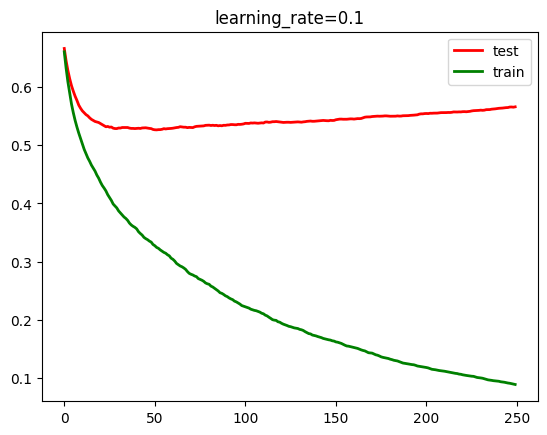

In [6]:
    plt.figure()
    plt.plot(test_loss, 'r', linewidth=2)
    plt.plot(train_loss, 'g', linewidth=2)
    plt.legend(['test', 'train'])
    plt.title(f'learning_rate={lr}')
    plt.show()

Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)?
Ответ: Overfitting

Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [8]:
train_loss, test_loss = results[0.2]

min_loss = min(test_loss)
best_iter = test_loss.index(min_loss)

print(round(min_loss, 2), best_iter)

0.53 36


Какое значение log-loss на тесте получается у этого случайного леса?

In [10]:
from sklearn.ensemble import RandomForestClassifier

best_iter = test_loss.index(min_loss)

rf = RandomForestClassifier(
    n_estimators=best_iter,
    random_state=241
)

rf.fit(X_train, y_train)

probs = rf.predict_proba(X_test)
rf_loss = log_loss(y_test, probs)

print(round(rf_loss, 2))

0.54
